In [30]:
import pandas as pd
import numpy as np

In [31]:
train_df = pd.read_csv('train.csv')

In [32]:
train_df.isnull().sum()

ImgId             0
title             1
description    1042
categories        0
dtype: int64

In [33]:
train_df = train_df.dropna(subset=["title"])

<Axes: xlabel='categories'>

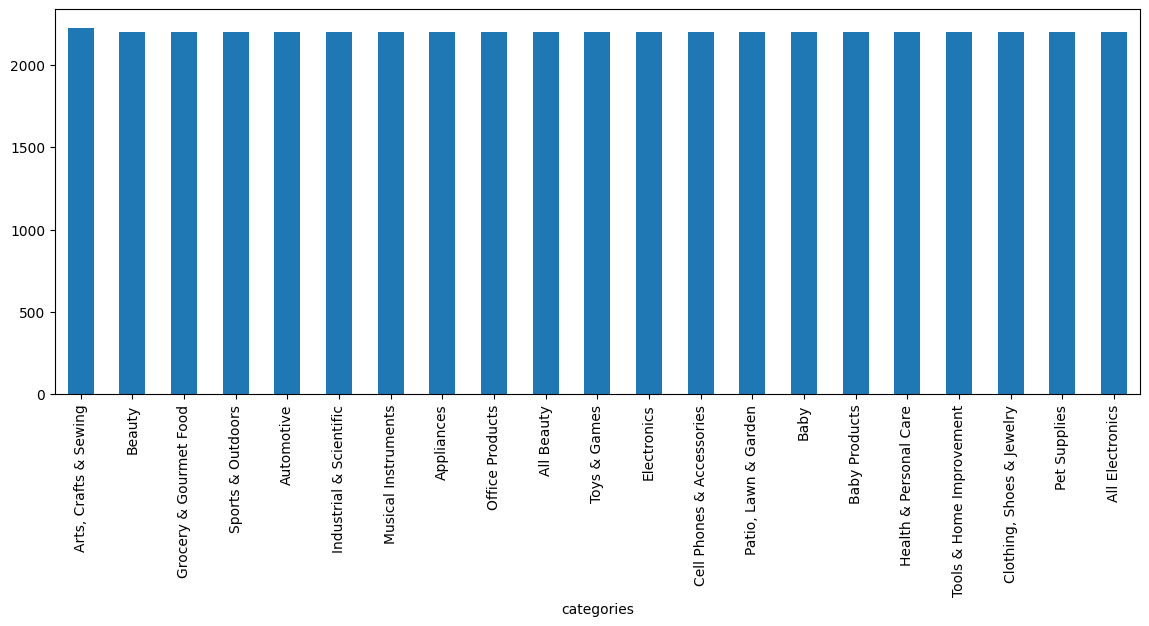

In [34]:
train_df['categories'].value_counts().plot(kind='bar',figsize=(14,5))

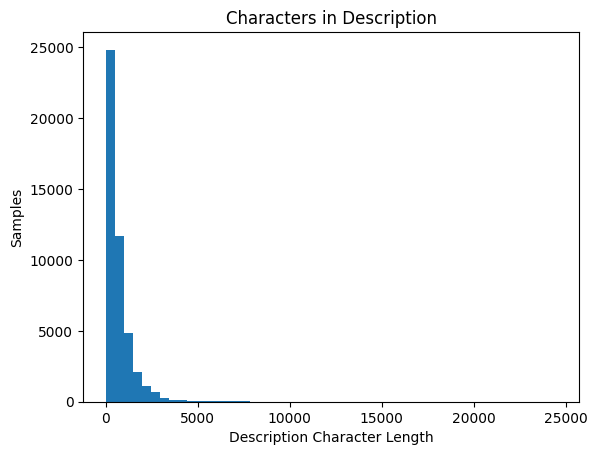

In [35]:
import matplotlib.pyplot as plt
word_len = train_df['description'].str.split().map(lambda x:len(str(x)))
plt.hist(word_len,bins=50)
plt.ylabel('Samples')
plt.xlabel('Description Character Length')
plt.title('Characters in Description')
plt.show()

In [36]:
import cv2
def load_images(df, folder):
    images = []
    valid_indices = []

    for idx, img_id in enumerate(df["ImgId"]):
        path = f"{folder}/{img_id}.jpg"

        img = cv2.imread(path)

        if img is None:
            # print("Could not load:", path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100,100))
        img = img.astype(np.float32)

        images.append(img)
        valid_indices.append(idx)

    return np.array(images), valid_indices

In [37]:
X_img_train, train_valid_idx = load_images(train_df, "train")
train_df = train_df.iloc[train_valid_idx].reset_index(drop=True)

In [39]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_train = le.fit_transform(train_df["categories"])

In [40]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [41]:
train_df["text"] = train_df["title"] + " " + train_df["description"].fillna("")

In [42]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 30000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(train_df["text"])

X_text_train = tokenizer.texts_to_sequences(train_df["text"])

X_text_train = pad_sequences(X_text_train, maxlen=max_len)

In [43]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [44]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense, Dropout
)

image_input = Input(shape=(100,100,3), name="img")

# Block 1
x = Conv2D(32, 3, activation='relu', padding='same')(image_input)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv2D(128, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = Dropout(0.3)(x)

# Feature vector
x = GlobalAveragePooling2D()(x)

image_features = Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

image_features = Dropout(0.5)(image_features)

In [45]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM

text_input = Input(shape=(max_len,),name="text")

text_branch = Embedding(
        input_dim=max_words,
        output_dim=128)(text_input)

text_branch = Bidirectional(
        LSTM(128))(text_branch)

text_branch = Dense(128, activation='relu')(text_branch)

In [46]:
from tensorflow.keras.layers import concatenate, Dropout
from tensorflow.keras import regularizers

combined = concatenate([image_features, text_branch])

combined = Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.001))(combined)
combined = Dropout(0.5)(combined)

output = Dense(21, activation='softmax')(combined)

In [47]:
from tensorflow.keras.models import Model

model = Model(
    inputs=[image_input, text_input],
    outputs=output
)

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [50]:
val_size = int(0.1 * len(X_img_train))

train_img = X_img_train[:-val_size]
val_img = X_img_train[-val_size:]

train_text = X_text_train[:-val_size]
val_text = X_text_train[-val_size:]

train_y = y_train[:-val_size]
val_y = y_train[-val_size:]

In [ ]:
import tensorflow as tf

with tf.device('/CPU:0'):
    train_ds = tf.data.Dataset.from_tensor_slices((
        {
            "img": train_img,
            "text": train_text
        },
        train_y
    ))

    val_ds = tf.data.Dataset.from_tensor_slices((
        {
            "img": val_img,
            "text": val_text
        },
        val_y
    ))

train_ds = train_ds.shuffle(10000).batch(16).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(16).prefetch(tf.data.AUTOTUNE)

history = model.fit(train_ds , validation_data=val_ds, epochs=10, callbacks=[early_stop])

Epoch 1/10
2363/2363 [==============================] - 158s 59ms/step - loss: 2.5589 - accuracy: 0.2073 - val_loss: 1.7453 - val_accuracy: 0.4395
Epoch 2/10
2363/2363 [==============================] - 144s 61ms/step - loss: 1.3947 - accuracy: 0.5643 - val_loss: 1.1386 - val_accuracy: 0.6590
Epoch 3/10
2363/2363 [==============================] - 142s 60ms/step - loss: 0.8550 - accuracy: 0.7542 - val_loss: 0.9533 - val_accuracy: 0.7302
Epoch 4/10
2363/2363 [==============================] - 151s 64ms/step - loss: 0.5866 - accuracy: 0.8416 - val_loss: 0.9858 - val_accuracy: 0.7517
Epoch 5/10
2076/2363 [=========================>....] - ETA: 16s - loss: 0.4099 - accuracy: 0.8940

In [ ]:
model.save("model.keras")

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))
plt.plot(epochs,acc,'r',label = 'Training Accuracy')
plt.plot(epochs,val_acc,'b',label = 'Validation Accuracy')
plt.title('Accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

In [ ]:
plt.plot(epochs,loss,'r',label = 'Training Loss')
plt.plot(epochs,val_loss,'b',label = 'Validation Loss')
plt.title('Loss')
plt.legend(loc=0)
plt.figure()
plt.show()